# SLSQP-JAX: Solver Configuration Benchmark

This notebook benchmarks the [slsqp-jax](https://github.com/lucianopaz/slsqp-jax) constrained optimizer under **different solver parameter configurations** on a suite of constrained optimization problems.

The goal is to compare how different algorithmic choices (active-set method, proximal stabilization, preconditioning, CG tolerance, L-BFGS memory) affect solve time, iteration count, and solution quality across problem types and scales.

### Problem classes

| # | Problem | Key feature |
|---|---------|-------------|
| 1 | Constrained Weighted Quadratic | Equality + inequality, active box constraints |
| 2 | Portfolio Optimization | Factor-model covariance, simplex + box |
| 3 | Constrained Rosenbrock | Nonlinear objective, linear constraints |
| 4 | Sphere with Mixed Constraints | Dense random equality + inequality |
| 5 | Ill-Conditioned Quadratic | Condition number ~1e6, tests preconditioner |
| 6 | Log-Barrier Portfolio | Objective undefined outside bounds, tests projected-SQP |

### Solver configurations

| Config | Key difference from default |
|--------|---------------------------|
| `default` | All defaults (`expand`, proximal on, preconditioner on) |
| `no_proximal` | `proximal_tau=0.0` (direct null-space projection) |
| `no_preconditioner` | `use_preconditioner=False` |
| `adaptive_cg` | `adaptive_cg_tol=True` |
| `lpeca_init` | `active_set_method='lpeca_init'` |
| `lpeca` | `active_set_method='lpeca'` |
| `large_memory` | `lbfgs_memory=20` |
| `newton_cg` | `use_exact_hvp_in_qp=True` (exact Hessian in QP) |
| `no_damping` | `damping_threshold=0.0` (no Powell damping) |

In [1]:
!uv pip install jax[cuda12] git+https://github.com/lucianopaz/slsqp-jax.git -q

zsh:1: no matches found: jax[cuda12]


In [2]:
import multiprocessing as mp
import time
from collections.abc import Callable
from dataclasses import dataclass, field
from typing import Optional

import cloudpickle
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx
import pandas as pd

from slsqp_jax import SLSQP
from slsqp_jax._benchmark_bootstrap import run_cloudpickled_task
from slsqp_jax.inner_solver import MinresQLPSolver, ProjectedCGCraig

jax.config.update("jax_enable_x64", True)

print(f"JAX version : {jax.__version__}")
print(f"Default device: {jax.devices()[0]}")

JAX version : 0.9.0
Default device: TFRT_CPU_0


## Solver configurations

Each entry maps a human-readable name to the SLSQP kwargs that differ from the defaults. To add a new configuration, just add another entry to the dict.

In [3]:
CONFIGS: dict[str, dict] = {
    "default": {},
    "no_proximal": {"proximal_tau": 0.0},
    "no_preconditioner": {"use_preconditioner": False, "proximal_tau": 0.0},
    "adaptive_cg": {"adaptive_cg_tol": True, "proximal_tau": 0.0},
    "lpeca_init": {"active_set_method": "lpeca_init", "proximal_tau": 0.0},
    "lpeca": {"active_set_method": "lpeca", "proximal_tau": 0.0},
    "large_memory": {"lbfgs_memory": 20, "proximal_tau": 0.0},
    "newton_cg_diag_pre": {
        "use_exact_hvp_in_qp": True,
        "proximal_tau": 0.0,
        "preconditioner_type": "diagonal",
    },
    "newton_cg": {
        "use_exact_hvp_in_qp": True,
        "proximal_tau": 0.0,
        "preconditioner_type": "lbfgs",
    },
    "no_damping": {"damping_threshold": 0.0, "proximal_tau": 0.0},
    "minres_qlp": {"inner_solver": MinresQLPSolver(), "proximal_tau": 0.0},
    "cg_craig_iterative": {
        "inner_solver": ProjectedCGCraig(max_cg_iter=200, cg_tol=1e-10),
        "proximal_tau": 0.0,
    },
}

## Problem generators

Each generator returns a `ProblemSpec` dataclass containing everything the benchmark harness needs.

In [4]:
@dataclass
class ProblemSpec:
    """Specification for a benchmark problem."""

    name: str
    n: int
    objective: Callable
    x0: jnp.ndarray
    n_eq: int = 0
    n_ineq: int = 0
    eq_fn: Optional[Callable] = None
    ineq_fn: Optional[Callable] = None
    bounds: Optional[jnp.ndarray] = None
    reference_obj: Optional[float] = None
    max_steps: int = 1000
    incompatible_configs: list[str] = field(default_factory=list)

In [5]:
def make_weighted_quadratic(n: int, seed: int = 0) -> ProblemSpec:
    """Constrained weighted quadratic (from the CPU vs GPU benchmark).

    min sum w_i (x_i - t_i)^2  s.t.  sum(x) = n,  x_j >= 0 for j=0..3
    """
    n_ineq = min(4, n)
    weights = jnp.linspace(1.0, 10.0, n)
    target = jnp.ones(n).at[:n_ineq].set(-2.0)

    def objective(x, args):
        return jnp.sum(weights * (x - target) ** 2), None

    def eq_constraint(x, args):
        return jnp.array([jnp.sum(x) - float(n)])

    def ineq_constraint(x, args):
        return x[:n_ineq]

    x0 = jnp.ones(n)

    return ProblemSpec(
        name=f"WeightedQuad(n={n})",
        n=n,
        objective=objective,
        x0=x0,
        n_eq=1,
        n_ineq=n_ineq,
        eq_fn=eq_constraint,
        ineq_fn=ineq_constraint,
    )

In [6]:
def make_portfolio(n: int, seed: int = 42) -> ProblemSpec:
    """Markowitz portfolio optimization with factor-model covariance.

    min (1/2) x^T Sigma x  s.t.  mu^T x >= r_target, 1^T x = 1, x >= 0
    where Sigma = F F^T + diag(d), F is n x k_factors.
    """
    rng = np.random.RandomState(seed)
    k_factors = min(10, n // 5)
    F = jnp.array(rng.randn(n, k_factors) * 0.1)
    d = jnp.array(np.abs(rng.randn(n)) * 0.05 + 0.01)
    mu = jnp.array(rng.rand(n) * 0.1 + 0.02)
    r_target = float(jnp.mean(mu)) * 1.2

    def objective(x, args):
        Fx = F.T @ x
        variance = jnp.dot(Fx, Fx) + jnp.dot(d * x, x)
        return 0.5 * variance, None

    def eq_constraint(x, args):
        return jnp.array([jnp.sum(x) - 1.0])

    def ineq_constraint(x, args):
        return jnp.array([jnp.dot(mu, x) - r_target])

    bounds = jnp.column_stack([jnp.zeros(n), jnp.ones(n)])
    x0 = jnp.ones(n) / n

    return ProblemSpec(
        name=f"Portfolio(n={n})",
        n=n,
        objective=objective,
        x0=x0,
        n_eq=1,
        n_ineq=1,
        eq_fn=eq_constraint,
        ineq_fn=ineq_constraint,
        bounds=bounds,
    )

In [7]:
def make_constrained_rosenbrock(n: int, seed: int = 0) -> ProblemSpec:
    """Rosenbrock function with linear equality and box constraints.

    min sum_{i=0}^{n-2} [100(x_{i+1} - x_i^2)^2 + (1 - x_i)^2]
    s.t. sum(x) = n, x >= 0
    """

    def objective(x, args):
        t1 = 100.0 * (x[1:] - x[:-1] ** 2) ** 2
        t2 = (1.0 - x[:-1]) ** 2
        return jnp.sum(t1 + t2), None

    def eq_constraint(x, args):
        return jnp.array([jnp.sum(x) - float(n)])

    bounds = jnp.column_stack([jnp.zeros(n), jnp.full(n, jnp.inf)])
    x0 = jnp.ones(n)

    return ProblemSpec(
        name=f"Rosenbrock(n={n})",
        n=n,
        objective=objective,
        x0=x0,
        n_eq=1,
        eq_fn=eq_constraint,
        bounds=bounds,
        reference_obj=0.0,
    )

In [8]:
def make_sphere_mixed(n: int, seed: int = 7) -> ProblemSpec:
    """Sphere objective with random dense equality + inequality constraints.

    min ||x||^2  s.t.  A_eq x = b_eq,  A_ineq x >= b_ineq
    """
    rng = np.random.RandomState(seed)
    m_eq = max(1, n // 10)
    m_ineq = max(1, n // 5)

    A_eq = jnp.array(rng.randn(m_eq, n))
    A_ineq = jnp.array(rng.randn(m_ineq, n))

    x_feas = jnp.array(rng.randn(n) * 0.1)
    b_eq = A_eq @ x_feas
    b_ineq = A_ineq @ x_feas - 0.5

    def objective(x, args):
        return jnp.dot(x, x), None

    def eq_constraint(x, args):
        return A_eq @ x - b_eq

    def ineq_constraint(x, args):
        return A_ineq @ x - b_ineq

    x0 = x_feas + jnp.array(rng.randn(n) * 0.01)

    return ProblemSpec(
        name=f"SphereMixed(n={n})",
        n=n,
        objective=objective,
        x0=x0,
        n_eq=m_eq,
        n_ineq=m_ineq,
        eq_fn=eq_constraint,
        ineq_fn=ineq_constraint,
    )

In [9]:
def make_ill_conditioned(n: int, seed: int = 13) -> ProblemSpec:
    """Ill-conditioned quadratic on the simplex.

    min (1/2) x^T H x  s.t.  sum(x) = 1,  x >= 0
    where H = Q diag(logspace(-2, 4, n)) Q^T, cond(H) ~ 1e6.
    """
    rng = np.random.RandomState(seed)
    Q_mat, _ = np.linalg.qr(rng.randn(n, n))
    eigvals = np.logspace(-2, 4, n)
    H = jnp.array(Q_mat @ np.diag(eigvals) @ Q_mat.T)

    def objective(x, args):
        return 0.5 * x @ H @ x, None

    def eq_constraint(x, args):
        return jnp.array([jnp.sum(x) - 1.0])

    bounds = jnp.column_stack([jnp.zeros(n), jnp.ones(n)])
    x0 = jnp.ones(n) / n

    return ProblemSpec(
        name=f"IllCond(n={n})",
        n=n,
        objective=objective,
        x0=x0,
        n_eq=1,
        eq_fn=eq_constraint,
        bounds=bounds,
    )

In [10]:
def make_log_barrier_portfolio(n: int, seed: int = 99) -> ProblemSpec:
    """Log-barrier portfolio: objective undefined outside bounds.

    min -sum log(x_i) + (lam/2) x^T Sigma x  s.t.  sum(x) = 1, x >= eps
    Tests projected-SQP: bounds must never be violated.
    """
    rng = np.random.RandomState(seed)
    k_factors = min(5, n // 5)
    F = jnp.array(rng.randn(n, k_factors) * 0.1)
    d = jnp.array(np.abs(rng.randn(n)) * 0.05 + 0.01)
    lam = 0.5
    eps = 1e-6

    def objective(x, args):
        Fx = F.T @ x
        variance = jnp.dot(Fx, Fx) + jnp.dot(d * x, x)
        return -jnp.sum(jnp.log(x)) + lam * 0.5 * variance, None

    def eq_constraint(x, args):
        return jnp.array([jnp.sum(x) - 1.0])

    bounds = jnp.column_stack([jnp.full(n, eps), jnp.ones(n)])
    x0 = jnp.ones(n) / n

    return ProblemSpec(
        name=f"LogBarrier(n={n})",
        n=n,
        objective=objective,
        x0=x0,
        n_eq=1,
        eq_fn=eq_constraint,
        bounds=bounds,
        incompatible_configs=["no_proximal"],
    )

## Problem suite

Generate all problem instances at the target sizes.

In [11]:
PROBLEMS: list[ProblemSpec] = [
    make_weighted_quadratic(100),
    make_weighted_quadratic(500),
    make_weighted_quadratic(1000),
    make_weighted_quadratic(5000),
    make_portfolio(100),
    make_portfolio(500),
    make_portfolio(1000),
    make_portfolio(5000),
    make_constrained_rosenbrock(20),
    make_constrained_rosenbrock(100),
    make_constrained_rosenbrock(500),
    make_sphere_mixed(100),
    make_sphere_mixed(500),
    make_sphere_mixed(1000),
    make_ill_conditioned(100),
    make_ill_conditioned(500),
    make_log_barrier_portfolio(100),
    make_log_barrier_portfolio(500),
]

print(f"{len(PROBLEMS)} problem instances across {6} problem classes")
for p in PROBLEMS:
    print(
        f"  {p.name:30s}  n={p.n:5d}  eq={p.n_eq}  ineq={p.n_ineq}  bounds={'yes' if p.bounds is not None else 'no'}"
    )

18 problem instances across 6 problem classes
  WeightedQuad(n=100)             n=  100  eq=1  ineq=4  bounds=no
  WeightedQuad(n=500)             n=  500  eq=1  ineq=4  bounds=no
  WeightedQuad(n=1000)            n= 1000  eq=1  ineq=4  bounds=no
  WeightedQuad(n=5000)            n= 5000  eq=1  ineq=4  bounds=no
  Portfolio(n=100)                n=  100  eq=1  ineq=1  bounds=yes
  Portfolio(n=500)                n=  500  eq=1  ineq=1  bounds=yes
  Portfolio(n=1000)               n= 1000  eq=1  ineq=1  bounds=yes
  Portfolio(n=5000)               n= 5000  eq=1  ineq=1  bounds=yes
  Rosenbrock(n=20)                n=   20  eq=1  ineq=0  bounds=yes
  Rosenbrock(n=100)               n=  100  eq=1  ineq=0  bounds=yes
  Rosenbrock(n=500)               n=  500  eq=1  ineq=0  bounds=yes
  SphereMixed(n=100)              n=  100  eq=10  ineq=20  bounds=no
  SphereMixed(n=500)              n=  500  eq=50  ineq=100  bounds=no
  SphereMixed(n=1000)             n= 1000  eq=100  ineq=200  bounds=no


## Benchmark harness

Each (problem, config) pair runs in a **fresh subprocess** (`multiprocessing` with `spawn` context). Problem closures and JAX arrays are serialized via `cloudpickle`.

1. Build the `SLSQP` solver with the config overrides.
2. JIT-compile with `.lower().compile()` (no full execution during warmup).
3. Run 1 post-compilation timed execution.
4. If the subprocess exceeds the timeout (10 min), it is killed and recorded as a timeout.

In [12]:
@dataclass
class BenchmarkResult:
    """Result from a single (problem, config) benchmark run."""

    problem_name: str
    config_name: str
    n: int
    wall_time_s: float
    obj_value: float
    eq_violation: float
    ineq_violation: float
    n_steps: int
    converged: bool
    error: Optional[str] = None


TIMEOUT_S = 600  # 10 minutes per scenario


def _make_result(problem_name, config_name, n, *, error):
    return BenchmarkResult(
        problem_name=problem_name,
        config_name=config_name,
        n=n,
        wall_time_s=float("nan"),
        obj_value=float("nan"),
        eq_violation=float("nan"),
        ineq_violation=float("nan"),
        n_steps=-1,
        converged=False,
        error=error,
    )


def run_benchmark(
    problem: ProblemSpec,
    config_name: str,
    config_kwargs: dict,
    timeout_s: int = TIMEOUT_S,
) -> BenchmarkResult:
    """Run a single (problem, config) benchmark in a spawned subprocess.

    Uses ``multiprocessing`` with ``spawn`` context so that each scenario
    runs in a fresh Python process.  Problem closures and JAX arrays are
    serialized via ``cloudpickle``.  If the subprocess exceeds *timeout_s*
    it is killed and a timeout result is returned.
    """
    objective = problem.objective
    eq_fn = problem.eq_fn
    ineq_fn = problem.ineq_fn
    n_eq = problem.n_eq
    n_ineq = problem.n_ineq
    bounds = problem.bounds
    max_steps = problem.max_steps
    x0 = problem.x0

    def task():
        import jax
        import jax.numpy as jnp

        solver = SLSQP(
            eq_constraint_fn=eq_fn,
            ineq_constraint_fn=ineq_fn,
            n_eq_constraints=n_eq,
            n_ineq_constraints=n_ineq,
            bounds=bounds,
            max_steps=max_steps,
            **config_kwargs,
        )

        @jax.jit
        def solve(x0_):
            return optx.minimise(
                objective,
                solver,
                x0_,
                has_aux=True,
                throw=False,
                max_steps=max_steps,
            )

        compiled = solve.lower(x0).compile()

        t0 = time.perf_counter()
        sol = compiled(x0)
        jax.block_until_ready(sol.value)
        wall_time = time.perf_counter() - t0

        x_sol = sol.value
        obj_val = float(objective(x_sol, None)[0])

        eq_viol = 0.0
        if eq_fn is not None:
            eq_res = eq_fn(x_sol, None)
            eq_viol = float(jnp.max(jnp.abs(eq_res)))

        ineq_viol = 0.0
        if ineq_fn is not None:
            ineq_res = ineq_fn(x_sol, None)
            ineq_viol = float(jnp.max(jnp.maximum(0.0, -ineq_res)))
        if bounds is not None:
            lb_viol = float(jnp.max(jnp.maximum(0.0, bounds[:, 0] - x_sol)))
            ub_viol = float(jnp.max(jnp.maximum(0.0, x_sol - bounds[:, 1])))
            ineq_viol = max(ineq_viol, lb_viol, ub_viol)

        return {
            "wall_time_s": wall_time,
            "obj_value": obj_val,
            "eq_violation": eq_viol,
            "ineq_violation": ineq_viol,
            "n_steps": int(sol.stats["num_steps"]),
            "converged": bool(sol.result == optx.RESULTS.successful),
        }

    task_bytes = cloudpickle.dumps(task)

    ctx = mp.get_context("spawn")
    q = ctx.Queue()
    p = ctx.Process(target=run_cloudpickled_task, args=(task_bytes, q))
    p.start()
    p.join(timeout=timeout_s)

    if p.is_alive():
        p.kill()
        p.join()
        return _make_result(
            problem.name,
            config_name,
            problem.n,
            error=f"Timeout ({timeout_s}s)",
        )

    try:
        status, payload = q.get_nowait()
    except Exception:
        return _make_result(
            problem.name,
            config_name,
            problem.n,
            error=f"Worker crashed (exit code {p.exitcode})",
        )

    if status == "ok":
        return BenchmarkResult(
            problem_name=problem.name,
            config_name=config_name,
            n=problem.n,
            **payload,
        )
    return _make_result(
        problem.name,
        config_name,
        problem.n,
        error=payload,
    )

## Run all benchmarks

In [ ]:
results: list[BenchmarkResult] = []

total = sum(1 for p in PROBLEMS for c in CONFIGS if c not in p.incompatible_configs)
counter = 0

for problem in PROBLEMS:
    for config_name, config_kwargs in CONFIGS.items():
        if config_name in problem.incompatible_configs:
            continue
        counter += 1
        print(
            f"[{counter:3d}/{total}] {problem.name:30s} | {config_name:20s}",
            end="",
            flush=True,
        )
        result = run_benchmark(problem, config_name, config_kwargs)
        results.append(result)
        status = "OK" if result.converged else "FAIL"
        if result.error and "Timeout" in result.error:
            status = "TMOUT"
        elif result.error:
            status = "ERR"
        if status == "TMOUT":
            print(f"  {status:5s}  {result.error}")
        else:
            print(f"  {status:5s}  {result.wall_time_s:8.4f}s  steps={result.n_steps}")

print(f"\nCompleted {len(results)} benchmark runs.")

[  1/214] WeightedQuad(n=100)            | default               OK       0.0037s  steps=4
[  2/214] WeightedQuad(n=100)            | no_proximal           OK       0.0020s  steps=2
[  3/214] WeightedQuad(n=100)            | no_preconditioner     FAIL     0.0614s  steps=140
[  4/214] WeightedQuad(n=100)            | adaptive_cg           OK       0.0014s  steps=2
[  5/214] WeightedQuad(n=100)            | lpeca_init            OK       0.0019s  steps=2
[  6/214] WeightedQuad(n=100)            | lpeca                 OK       0.0021s  steps=2
[  7/214] WeightedQuad(n=100)            | large_memory          OK       0.0045s  steps=2
[  8/214] WeightedQuad(n=100)            | newton_cg_diag_pre    OK       0.0012s  steps=1
[  9/214] WeightedQuad(n=100)            | newton_cg             OK       0.0016s  steps=1
[ 10/214] WeightedQuad(n=100)            | no_damping            OK       0.0021s  steps=2
[ 11/214] WeightedQuad(n=100)            | minres_qlp            OK       0.0068s  steps

## Results

In [ ]:
df = pd.DataFrame(
    [
        {
            "problem": r.problem_name,
            "config": r.config_name,
            "n": r.n,
            "time_s": r.wall_time_s,
            "objective": r.obj_value,
            "eq_viol": r.eq_violation,
            "ineq_viol": r.ineq_violation,
            "steps": r.n_steps,
            "converged": r.converged,
            "error": r.error,
        }
        for r in results
    ]
)

df["problem_class"] = df["problem"].str.extract(r"^(\w+)")

styled = df.drop(columns=["error"]).style.format(
    {
        "time_s": "{:.4f}",
        "objective": "{:.6e}",
        "eq_viol": "{:.2e}",
        "ineq_viol": "{:.2e}",
    }
)
styled = styled.background_gradient(subset=["time_s"], cmap="RdYlGn_r")  # type: ignore[attr-defined]
styled

,problem,config,n,time_s,objective,eq_viol,ineq_viol,steps,converged,problem_class
0,WeightedQuad(n=100),default,100,0.0037,1.889811e+01,2.38e-11,6.72e-15,4,True,WeightedQuad
1,WeightedQuad(n=100),no_proximal,100,0.0023,1.889811e+01,1.01e-10,1.02e-10,2,True,WeightedQuad
2,WeightedQuad(n=100),no_preconditioner,100,0.0098,1.889811e+01,3.70e-09,4.89e-08,20,True,WeightedQuad
3,WeightedQuad(n=100),adaptive_cg,100,0.0014,1.889811e+01,1.01e-10,1.02e-10,2,True,WeightedQuad
4,WeightedQuad(n=100),lpeca_init,100,0.0022,1.889811e+01,1.01e-10,1.02e-10,2,True,WeightedQuad
5,WeightedQuad(n=100),lpeca,100,0.0020,1.889811e+01,1.01e-10,1.02e-10,2,True,WeightedQuad
6,WeightedQuad(n=100),large_memory,100,0.0029,1.889811e+01,1.01e-10,1.02e-10,2,True,WeightedQuad
7,WeightedQuad(n=100),newton_cg_diag_pre,100,0.0012,1.889811e+01,4.17e-10,0.00e+00,1,True,WeightedQuad
8,WeightedQuad(n=100),newton_cg,100,0.0016,1.889811e+01,4.17e-10,0.00e+00,1,True,WeightedQuad
9,WeightedQuad(n=100),no_damping,100,0.0020,1.889811e+01,1.01e-10,1.02e-10,2,True,WeightedQuad


## Visualization

### Solve time by problem and config

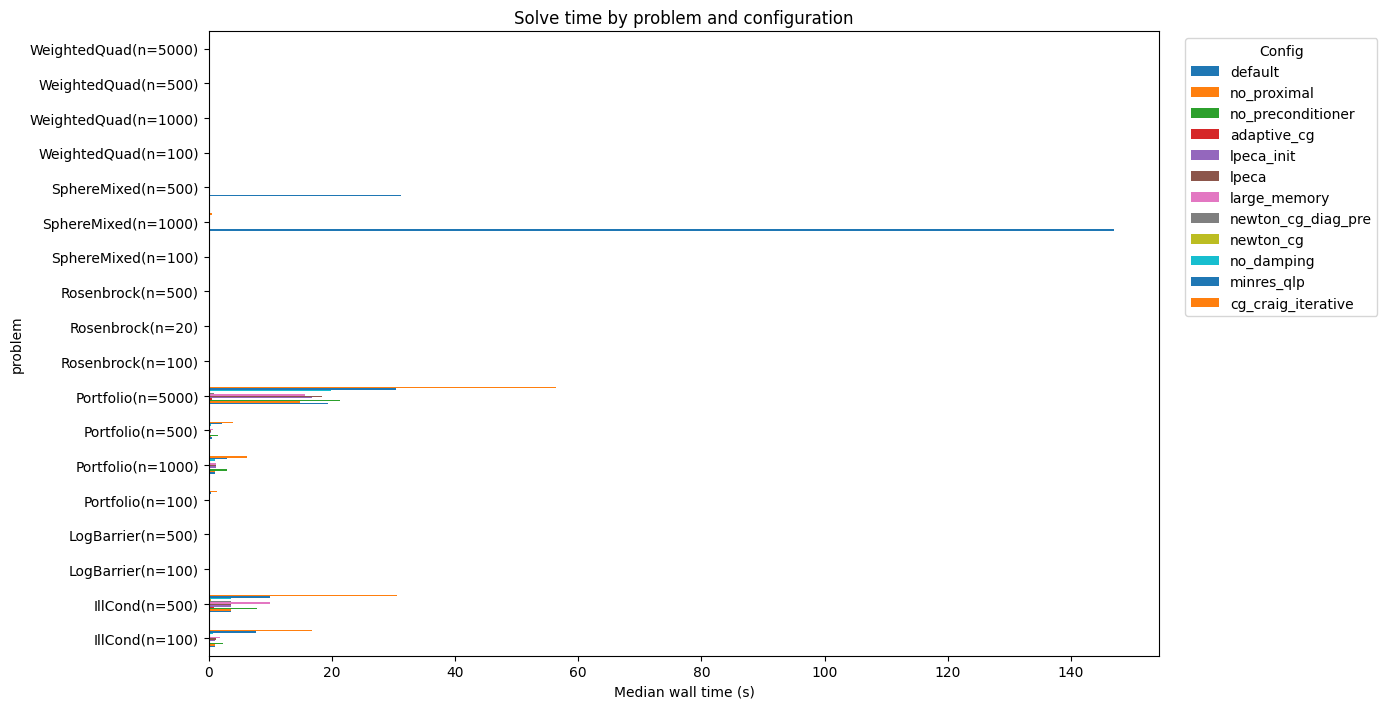

In [ ]:
pivot_time = df.pivot_table(index="problem", columns="config", values="time_s")
pivot_time = pivot_time.reindex(columns=[c for c in CONFIGS if c in pivot_time.columns])

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot_time) * 0.4)))
pivot_time.plot.barh(ax=ax)
ax.set_xlabel("Median wall time (s)")
ax.set_title("Solve time by problem and configuration")
ax.legend(title="Config", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Iteration count by problem and config

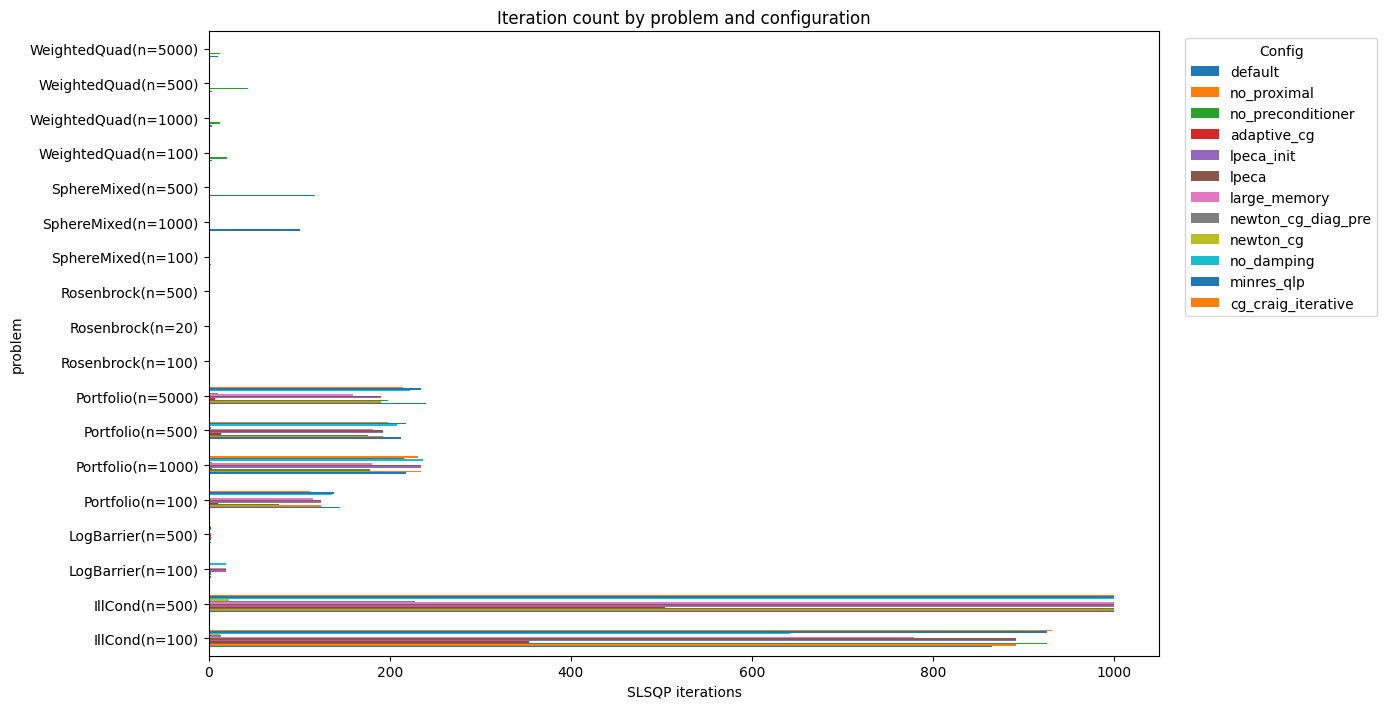

In [ ]:
pivot_steps = df.pivot_table(index="problem", columns="config", values="steps")
pivot_steps = pivot_steps.reindex(
    columns=[c for c in CONFIGS if c in pivot_steps.columns]
)

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot_steps) * 0.4)))
pivot_steps.plot.barh(ax=ax)
ax.set_xlabel("SLSQP iterations")
ax.set_title("Iteration count by problem and configuration")
ax.legend(title="Config", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Performance profile

For each configuration, what fraction of problems are solved within $\tau$ times the fastest solver's time?

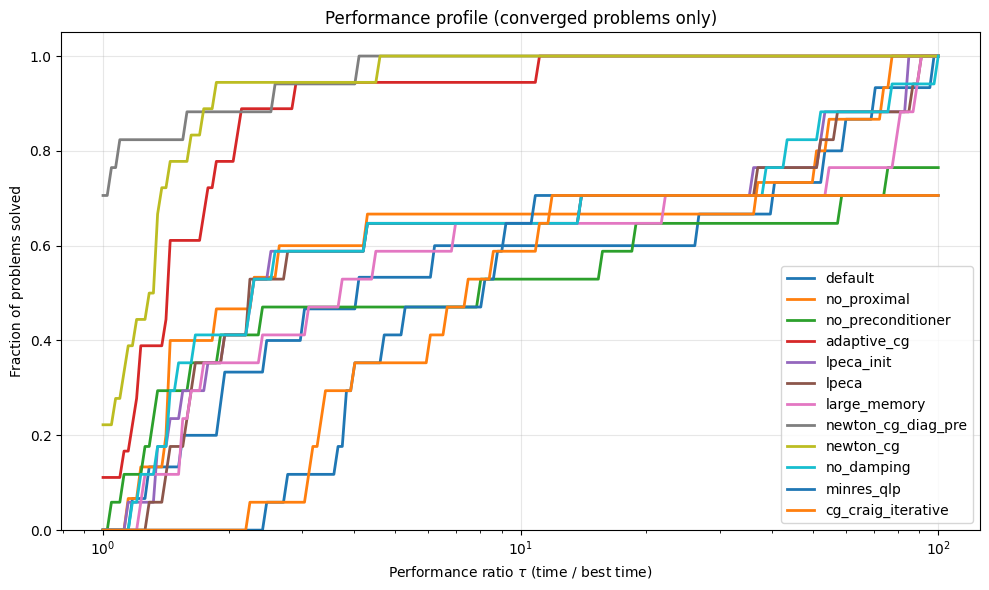

In [ ]:
df_ok = df[df["converged"]].copy()

best_time = df_ok.groupby("problem")["time_s"].min()
df_ok = df_ok.merge(best_time.rename("best_time"), on="problem")
df_ok["ratio"] = df_ok["time_s"] / df_ok["best_time"]

tau_range = np.logspace(0, 2, 200)

fig, ax = plt.subplots(figsize=(10, 6))
for config_name in CONFIGS:
    subset = df_ok[df_ok["config"] == config_name]
    if len(subset) == 0:
        continue
    n_problems = len(subset)
    fractions = [
        float((subset["ratio"] <= tau).sum()) / n_problems for tau in tau_range
    ]
    ax.plot(tau_range, fractions, label=config_name, linewidth=2)

ax.set_xscale("log")
ax.set_xlabel(r"Performance ratio $\tau$ (time / best time)")
ax.set_ylabel("Fraction of problems solved")
ax.set_title("Performance profile (converged problems only)")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Convergence summary heatmap

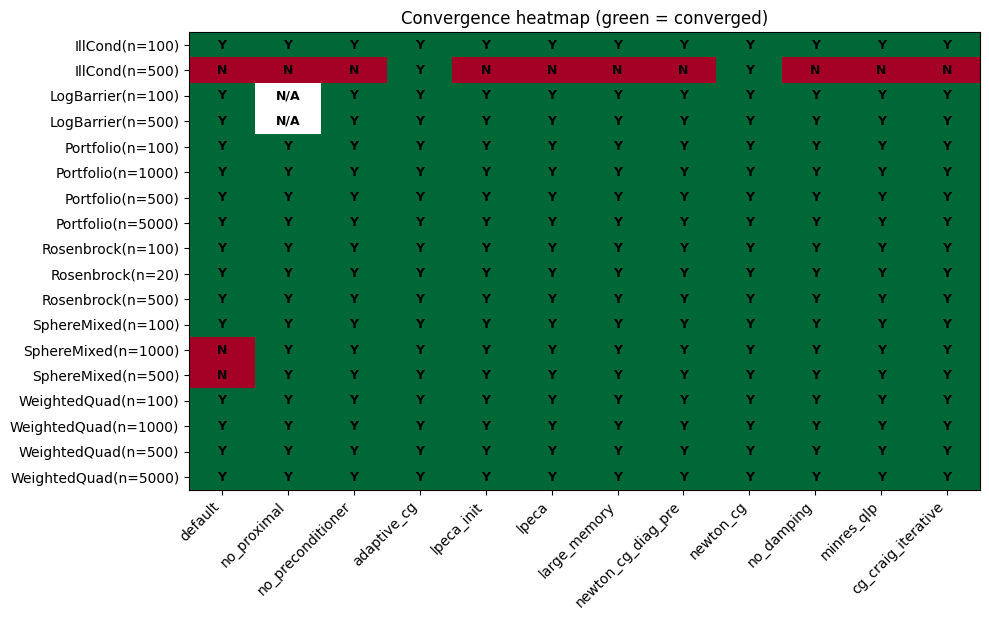

In [ ]:
pivot_conv = df.pivot_table(
    index="problem", columns="config", values="converged", aggfunc="first"
)
pivot_conv = pivot_conv.reindex(columns=[c for c in CONFIGS if c in pivot_conv.columns])

# Build a lookup for timeout errors
timeout_lookup = (
    df[df["error"].str.startswith("Timeout", na=False)]
    .set_index(["problem", "config"])
    .index
)

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_conv) * 0.35)))
im = ax.imshow(
    pivot_conv.values.astype(float), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1
)
ax.set_xticks(range(len(pivot_conv.columns)))
ax.set_xticklabels(pivot_conv.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_conv.index)))
ax.set_yticklabels(pivot_conv.index)
ax.set_title("Convergence heatmap (green = converged)")

for i in range(len(pivot_conv.index)):
    for j in range(len(pivot_conv.columns)):
        val = pivot_conv.values[i, j]
        prob = pivot_conv.index[i]
        cfg = pivot_conv.columns[j]
        if np.isnan(val):
            text = "N/A"
        elif (prob, cfg) in timeout_lookup:
            text = "T/O"
        else:
            text = "Y" if val else "N"
        ax.text(j, i, text, ha="center", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

### Objective quality: gap from best solution

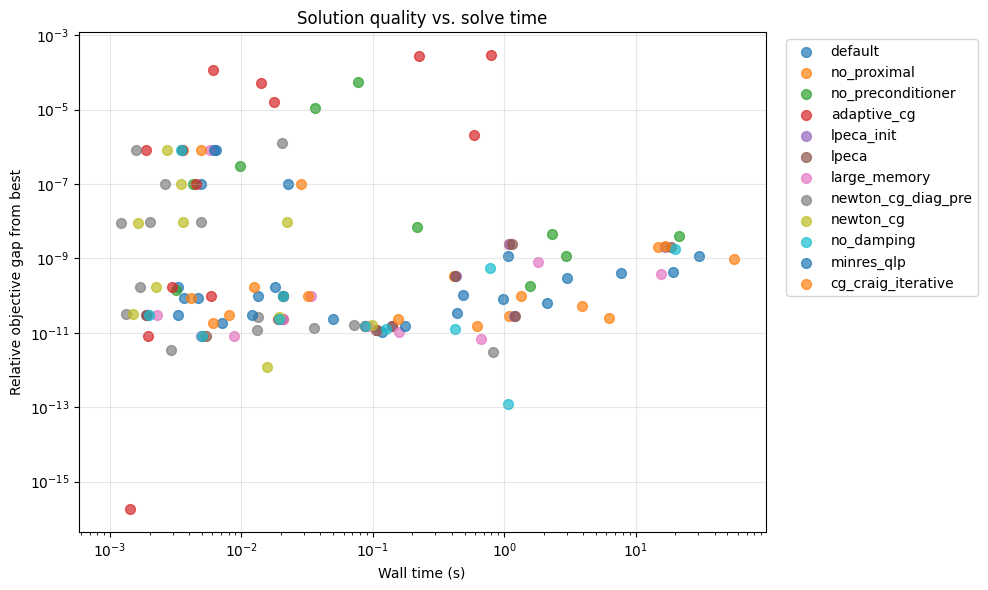

In [ ]:
best_obj = df_ok.groupby("problem")["objective"].min()
df_gap = df_ok.merge(best_obj.rename("best_obj"), on="problem")
df_gap["obj_gap"] = (df_gap["objective"] - df_gap["best_obj"]).abs() / (
    1.0 + df_gap["best_obj"].abs()
)

fig, ax = plt.subplots(figsize=(10, 6))
for config_name in CONFIGS:
    subset = df_gap[df_gap["config"] == config_name]
    if len(subset) == 0:
        continue
    ax.scatter(subset["time_s"], subset["obj_gap"], label=config_name, alpha=0.7, s=50)

ax.set_xlabel("Wall time (s)")
ax.set_ylabel("Relative objective gap from best")
ax.set_title("Solution quality vs. solve time")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Per-class summary

In [ ]:
summary = (
    df[df["converged"]]
    .groupby(["problem_class", "config"])
    .agg(
        solved=("converged", "sum"),
        mean_time=("time_s", "mean"),
        mean_steps=("steps", "mean"),
        max_eq_viol=("eq_viol", "max"),
        max_ineq_viol=("ineq_viol", "max"),
    )
    .round(4)
)

summary

solved  mean_time  mean_steps  max_eq_viol  \
problem_class config                                                           
IllCond       adaptive_cg              2     0.5062      429.00          0.0   
              cg_craig_iterative       1    16.7189      931.00          0.0   
              default                  1     1.0703      865.00          0.0   
              large_memory             1     1.8191      779.00          0.0   
              lpeca                    1     1.1475      892.00          0.0   
...                                  ...        ...         ...          ...   
WeightedQuad  newton_cg                4     0.0075        1.00          0.0   
              newton_cg_diag_pre       4     0.0024        1.00          0.0   
              no_damping               4     0.0078        2.00          0.0   
              no_preconditioner        4     0.0536       22.25          0.0   
              no_proximal              4     0.0079        2.00          0.0   

                                  max_ineq_viol  
problem_class config                             
IllCond       adaptive_cg                   0.0  
              cg_craig_iterative            0.0  
              default                       0.0  
              large_memory                  0.0  
              lpeca                         0.0  
...                                         ...  
WeightedQuad  newton_cg                     0.0  
              newton_cg_diag_pre            0.0  
              no_damping                    0.0  
              no_preconditioner             0.0  
              no_proximal                   0.0  

[71 rows x 5 columns]

## Summary

The tables and plots above show how each solver configuration performs across the six problem classes. Key things to look for:

- **`default` vs `no_proximal`**: Does sSQP proximal stabilization help or hurt on equality-constrained problems?
- **`default` vs `no_preconditioner`**: How much does the L-BFGS preconditioner speed up convergence, especially on ill-conditioned problems?
- **`default` vs `adaptive_cg`**: Does loosening the CG tolerance early save iterations without sacrificing solution quality?
- **`default` vs `lpeca_init` / `lpeca`**: Does LPEC-A active-set prediction reduce QP iterations?
- **`default` vs `large_memory`**: Does extra L-BFGS history help on larger or harder problems?
- **`default` vs `newton_cg`**: Does exact Hessian in the QP (Newton-CG) help on ill-conditioned problems?
- **`default` vs `no_damping`**: Does disabling Powell damping improve convergence on well-conditioned PD objectives?
- **`LogBarrier`**: Which configs can handle objectives that are undefined outside the feasible region?